# 2019 German day-ahead price validation

This notebook compares the simulated EOM clearing prices with the SMARD Germany/Luxembourg hourly day-ahead series. It checks data completeness, handles the daylight-saving-time hour explicitly, reports correlation and price-level errors, and visualizes the results by time, month, and hour of day.

The inputs are expected in `examples/outputs/example_2019_update_base_case_2019/`: `market_meta.csv` and `Gro_handelspreise_201901010000_202001010000_Stunde.xlsx`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.3f}".format

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "examples").is_dir())
results_dir = repo_root / "examples/outputs/example_2019_update_base_case_2019"
market_meta_path = results_dir / "market_meta.csv"
actual_price_path = results_dir / "Gro_handelspreise_201901010000_202001010000_Stunde.xlsx"

assert market_meta_path.exists(), f"Missing simulation results: {market_meta_path}"
assert actual_price_path.exists(), f"Missing SMARD workbook: {actual_price_path}"
print(f"Results folder: {results_dir}")

Results folder: /root/assume/examples/outputs/example_2019_update_base_case_2019


In [2]:
# Simulated day-ahead prices: one EOM clearing price for each delivery hour.
market_meta = pd.read_csv(market_meta_path)
simulated = (
    market_meta.loc[market_meta["market_id"].eq("EOM"), ["product_start", "price"]]
    .rename(columns={"product_start": "time", "price": "simulated_eom"})
    .assign(time=lambda frame: pd.to_datetime(frame["time"]))
    .sort_values("time")
    .reset_index(drop=True)
)

# The German/Luxembourg series is the third column in the SMARD export.
actual = pd.read_excel(actual_price_path, sheet_name="Großhandelspreise", header=9, usecols=[0, 2])
actual.columns = ["time", "actual_da"]
actual = (
    actual.assign(
        time=lambda frame: pd.to_datetime(frame["time"], dayfirst=True, errors="coerce"),
        actual_da=lambda frame: pd.to_numeric(frame["actual_da"], errors="coerce"),
    )
    .dropna(subset=["time", "actual_da"])
    .reset_index(drop=True)
)

# SMARD retains both autumn daylight-saving 02:00 hours and omits spring 02:00.
# The simulator uses a naive hourly index, so we average the duplicated autumn
# observation and compare only common local-clock timestamps.
actual_by_clock = actual.groupby("time", as_index=False)["actual_da"].mean()
paired = simulated.merge(actual_by_clock, on="time", how="inner", validate="one_to_one")
paired["error"] = paired["simulated_eom"] - paired["actual_da"]
paired["month"] = paired["time"].dt.to_period("M")
paired["hour"] = paired["time"].dt.hour

print(f"Simulated EOM hours: {len(simulated):,}")
print(f"SMARD price rows: {len(actual):,}; unique local-clock hours: {len(actual_by_clock):,}")
print(f"Matched hours: {len(paired):,} ({paired.time.min():%Y-%m-%d %H:%M} to {paired.time.max():%Y-%m-%d %H:%M})")

/root/assume/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Simulated EOM hours: 8,760
SMARD price rows: 8,760; unique local-clock hours: 8,759
Matched hours: 8,759 (2019-01-01 00:00 to 2019-12-31 23:00)


In [3]:
# Reproducible robustness checks. Change MIN_PEARSON if a different
# acceptance target is agreed for future calibrated scenarios.
MIN_MATCHED_HOURS = 8_700
MIN_PEARSON = 0.65

metrics = pd.Series({
    "matched hours": len(paired),
    "Pearson correlation": paired["simulated_eom"].corr(paired["actual_da"], method="pearson"),
    "Spearman correlation": paired["simulated_eom"].corr(paired["actual_da"], method="spearman"),
    "mean simulated price (EUR/MWh)": paired["simulated_eom"].mean(),
    "mean actual price (EUR/MWh)": paired["actual_da"].mean(),
    "mean bias, simulated - actual (EUR/MWh)": paired["error"].mean(),
    "MAE (EUR/MWh)": paired["error"].abs().mean(),
    "RMSE (EUR/MWh)": np.sqrt((paired["error"] ** 2).mean()),
})
display(metrics.to_frame("value"))

checks = pd.DataFrame({
    "check": ["All EOM timestamps unique", "Sufficient common hours", "Finite paired prices", "Pearson target"],
    "passed": [
        simulated["time"].is_unique,
        len(paired) >= MIN_MATCHED_HOURS,
        np.isfinite(paired[["simulated_eom", "actual_da"]]).all().all(),
        metrics["Pearson correlation"] >= MIN_PEARSON,
    ],
})
display(checks)
assert checks["passed"].all(), "At least one robustness check failed."

,value
matched hours,8759.000
Pearson correlation,0.713
Spearman correlation,0.820
mean simulated price (EUR/MWh),23.017
mean actual price (EUR/MWh),37.673
"mean bias, simulated - actual (EUR/MWh)",-14.656
MAE (EUR/MWh),16.481
RMSE (EUR/MWh),18.331


,check,passed
0,All EOM timestamps unique,True
1,Sufficient common hours,True
2,Finite paired prices,True
3,Pearson target,True


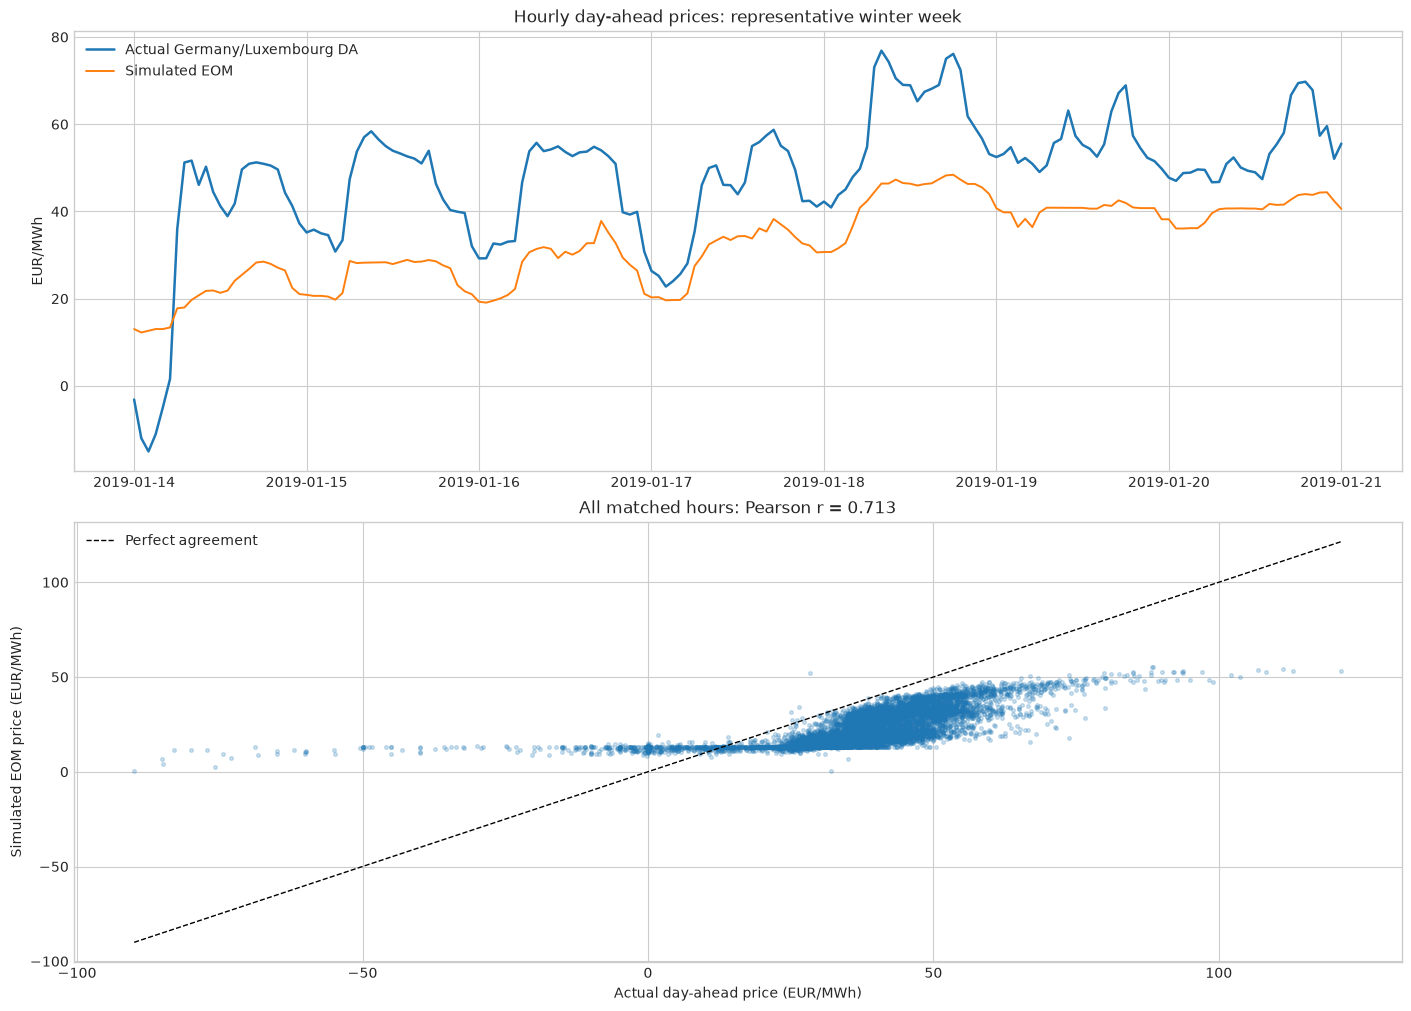

In [4]:
# Hourly comparison for a representative winter week and price scatter.
week = paired.loc[paired["time"].between("2019-01-14", "2019-01-21")].copy()
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

axes[0].plot(week["time"], week["actual_da"], label="Actual Germany/Luxembourg DA", lw=1.8)
axes[0].plot(week["time"], week["simulated_eom"], label="Simulated EOM", lw=1.4)
axes[0].set(title="Hourly day-ahead prices: representative winter week", ylabel="EUR/MWh")
axes[0].legend()

axes[1].scatter(paired["actual_da"], paired["simulated_eom"], s=7, alpha=0.22)
lower = min(paired[["actual_da", "simulated_eom"]].min())
upper = max(paired[["actual_da", "simulated_eom"]].max())
axes[1].plot([lower, upper], [lower, upper], "k--", lw=1, label="Perfect agreement")
axes[1].set(
    title=f"All matched hours: Pearson r = {metrics['Pearson correlation']:.3f}",
    xlabel="Actual day-ahead price (EUR/MWh)",
    ylabel="Simulated EOM price (EUR/MWh)",
)
axes[1].legend()
plt.show()

,pearson,simulated_mean,actual_mean,bias,mae
month,,,,,
2019-01,0.848,33.327,49.393,-16.066,19.009
2019-02,0.836,29.489,42.821,-13.331,14.146
2019-03,0.727,19.501,30.627,-11.126,14.436
2019-04,0.522,22.739,36.956,-14.217,16.724
2019-05,0.657,18.351,37.844,-19.492,20.319
2019-06,0.624,15.630,32.518,-16.888,21.191
2019-07,0.818,21.649,39.685,-18.036,18.077
2019-08,0.687,20.301,36.848,-16.547,17.674
2019-09,0.723,19.775,35.751,-15.976,17.082


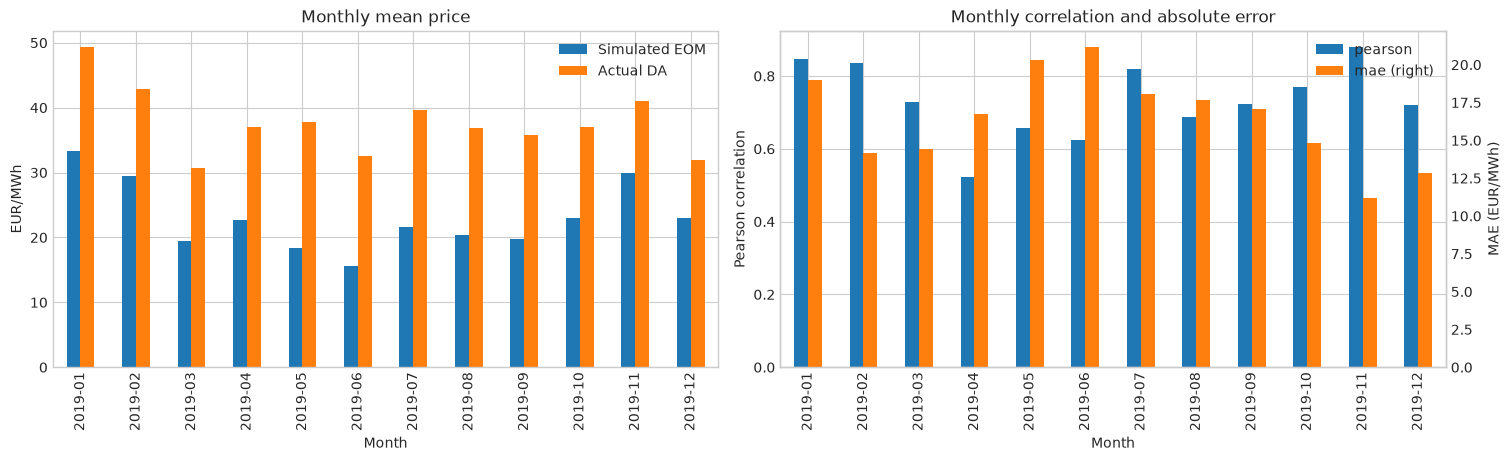

In [5]:
# Monthly robustness: does the relationship remain stable throughout the year?
monthly = paired.groupby("month").agg(
    pearson=("simulated_eom", lambda series: series.corr(paired.loc[series.index, "actual_da"])),
    simulated_mean=("simulated_eom", "mean"),
    actual_mean=("actual_da", "mean"),
    bias=("error", "mean"),
    mae=("error", lambda series: series.abs().mean()),
)
display(monthly)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
monthly[["simulated_mean", "actual_mean"]].plot(kind="bar", ax=axes[0])
axes[0].set(title="Monthly mean price", xlabel="Month", ylabel="EUR/MWh")
axes[0].legend(["Simulated EOM", "Actual DA"])
monthly[["pearson", "mae"]].plot(kind="bar", secondary_y="mae", ax=axes[1])
axes[1].set(title="Monthly correlation and absolute error", xlabel="Month", ylabel="Pearson correlation")
axes[1].right_ax.set_ylabel("MAE (EUR/MWh)")
plt.show()

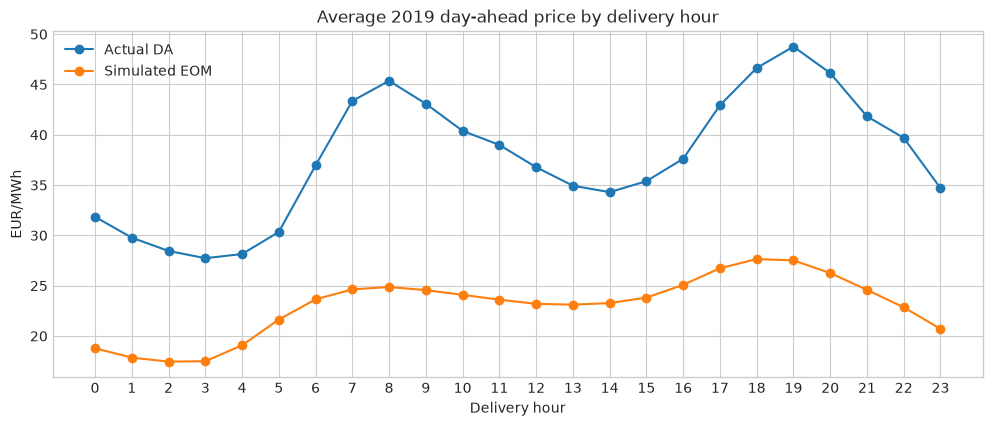

Interpretation: r=0.713 indicates a positive hourly co-movement; the mean bias of -14.66 EUR/MWh shows whether the model price level is systematically too high or too low.


In [6]:
# Average day-ahead delivery-hour shape: this is not an intraday-market price.
hourly = paired.groupby("hour")[["simulated_eom", "actual_da"]].mean()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(hourly.index, hourly["actual_da"], marker="o", label="Actual DA")
ax.plot(hourly.index, hourly["simulated_eom"], marker="o", label="Simulated EOM")
ax.set(
    title="Average 2019 day-ahead price by delivery hour",
    xlabel="Delivery hour",
    ylabel="EUR/MWh",
    xticks=range(24),
)
ax.legend()
plt.show()

print(
    f"Interpretation: r={metrics['Pearson correlation']:.3f} indicates a positive hourly co-movement; "
    f"the mean bias of {metrics['mean bias, simulated - actual (EUR/MWh)']:.2f} EUR/MWh "
    "shows whether the model price level is systematically too high or too low."
)

## CRM positive and negative reserve outcomes

The annual case clears both CRM markets in four-hour capacity blocks. The following cells validate market coverage and volume balance, then compare clearing-price and procured-capacity outcomes. No external CRM benchmark is used here; this section assesses the internal consistency and behaviour of the simulated markets.

## CRM capacity-price analysis

`CRM_pos` and `CRM_neg` identify upward and downward balancing directions. The model records the downward-direction (`CRM_neg`) capacity price with a negative sign. For a like-for-like capacity-remuneration analysis, this section uses its positive magnitude, `abs(price)`, while retaining the raw signed value for traceability. This is an analysis convention only; it does not alter model bids or clearing.

In [7]:
crm_markets = ["CRM_pos", "CRM_neg"]
crm = market_meta.loc[market_meta["market_id"].isin(crm_markets)].copy()
crm["time"] = pd.to_datetime(crm["product_start"])
crm["month"] = crm["time"].dt.to_period("M")
crm["duration_hours"] = (pd.to_datetime(crm["product_end"]) - crm["time"]).dt.total_seconds() / 3600
crm["capacity_balance"] = crm["supply_volume"] - crm["demand_volume"]
crm["model_price"] = crm["price"]
crm["capacity_price"] = crm["price"].abs()

assert set(crm_markets).issubset(set(crm["market_id"])), "One or both CRM markets are missing."
assert crm.groupby("market_id")["time"].apply(lambda series: series.is_unique).all(), "Duplicate CRM delivery blocks found."
assert np.isclose(crm["capacity_balance"], 0).all(), "CRM demand was not balanced by cleared supply."
assert crm["duration_hours"].eq(4).all(), "Unexpected CRM product duration."

crm_summary = crm.groupby("market_id").agg(
    cleared_blocks=("time", "size"),
    first_delivery=("time", "min"),
    last_delivery=("time", "max"),
    mean_capacity_price=("capacity_price", "mean"),
    median_capacity_price=("capacity_price", "median"),
    min_capacity_price=("capacity_price", "min"),
    max_capacity_price=("capacity_price", "max"),
    mean_model_price=("model_price", "mean"),
    mean_cleared_capacity_mw=("supply_volume", "mean"),
    total_capacity_energy_mwh=("supply_volume_energy", "sum"),
    max_abs_capacity_imbalance_mw=("capacity_balance", lambda series: series.abs().max()),
)
display(crm_summary)

,cleared_blocks,first_delivery,last_delivery,mean_capacity_price,median_capacity_price,min_capacity_price,max_capacity_price,mean_model_price,mean_cleared_capacity_mw,total_capacity_energy_mwh,max_abs_capacity_imbalance_mw
market_id,,,,,,,,,,,
CRM_neg,2190,2019-01-01,2019-12-31 20:00:00,4.039,0.343,0.000,141.340,-4.039,2824.779,24745060.000,0.000
CRM_pos,2190,2019-01-01,2019-12-31 20:00:00,11.906,9.080,0.015,115.010,11.906,3307.735,28975756.000,0.000


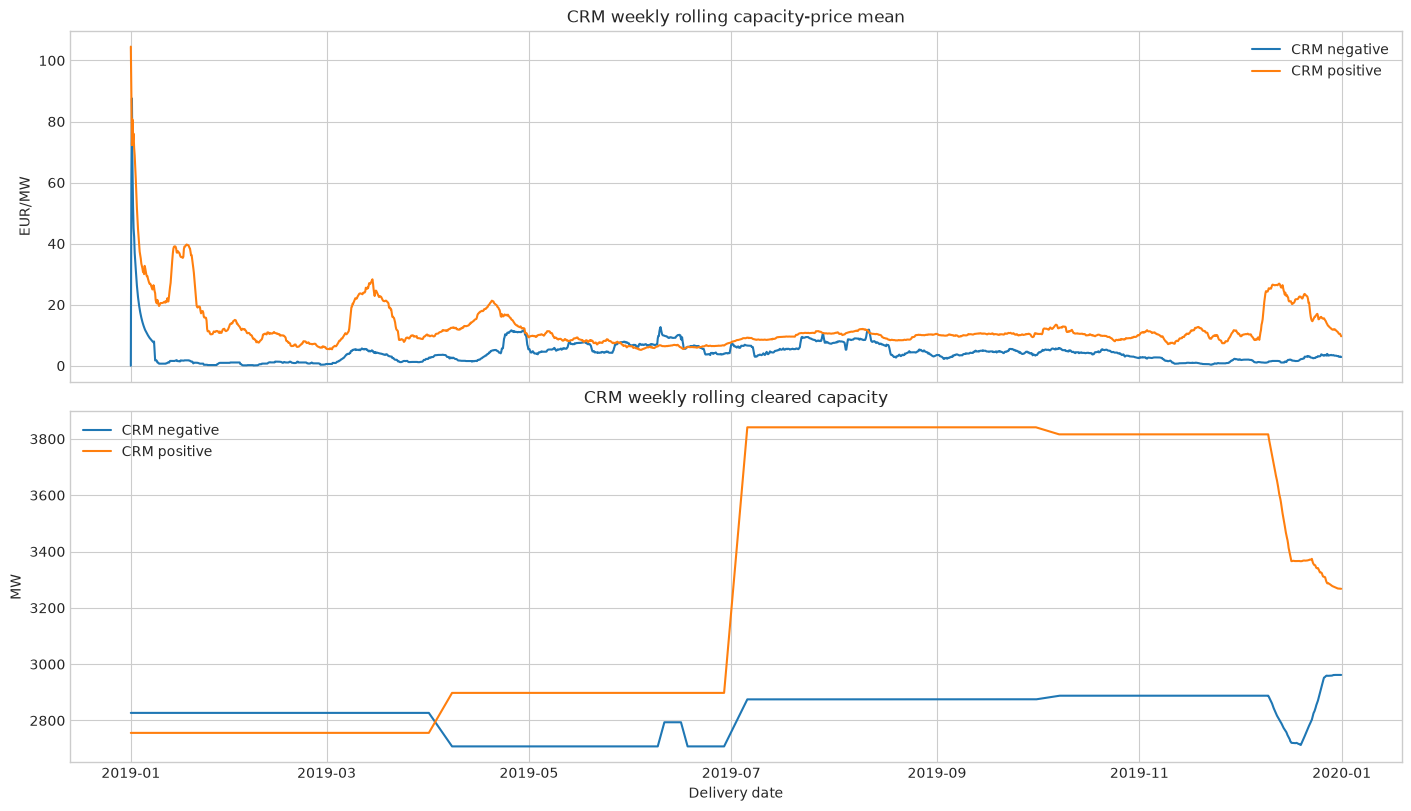

In [8]:
# Price dynamics and cleared capacity. A 42-block window corresponds to one week.
weekly = crm.set_index("time").groupby("market_id")[["capacity_price", "supply_volume"]].rolling(42, min_periods=1).mean().reset_index()
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)
for market, frame in weekly.groupby("market_id"):
    label = "CRM positive" if market == "CRM_pos" else "CRM negative"
    axes[0].plot(frame["time"], frame["capacity_price"], label=label)
    axes[1].plot(frame["time"], frame["supply_volume"], label=label)
axes[0].set(title="CRM weekly rolling capacity-price mean", ylabel="EUR/MW")
axes[1].set(title="CRM weekly rolling cleared capacity", ylabel="MW", xlabel="Delivery date")
axes[0].legend()
axes[1].legend()
plt.show()

mean_capacity_price         mean_cleared_capacity_mw         
market_id             CRM_neg CRM_pos                  CRM_neg  CRM_pos
month                                                                  
2019-01                 2.531  22.844                 2827.000 2756.000
2019-02                 0.763   7.809                 2827.000 2756.024
2019-03                 3.153  15.106                 2827.000 2756.016
2019-04                 4.957  14.084                 2708.000 2898.000
2019-05                 5.954   8.301                 2708.000 2898.000
2019-06                 6.818   6.487                 2739.133 2960.867
2019-07                 6.385   9.815                 2875.000 3841.000
2019-08                 5.635  10.090                 2875.000 3841.005
2019-09                 4.242  10.251                 2875.000 3841.000
2019-10                 4.157  10.237                 2888.000 3816.000
2019-11                 1.479  10.135                 2888.000 3816.000
2019-12                 2.122  17.106                 2857.554 3468.704

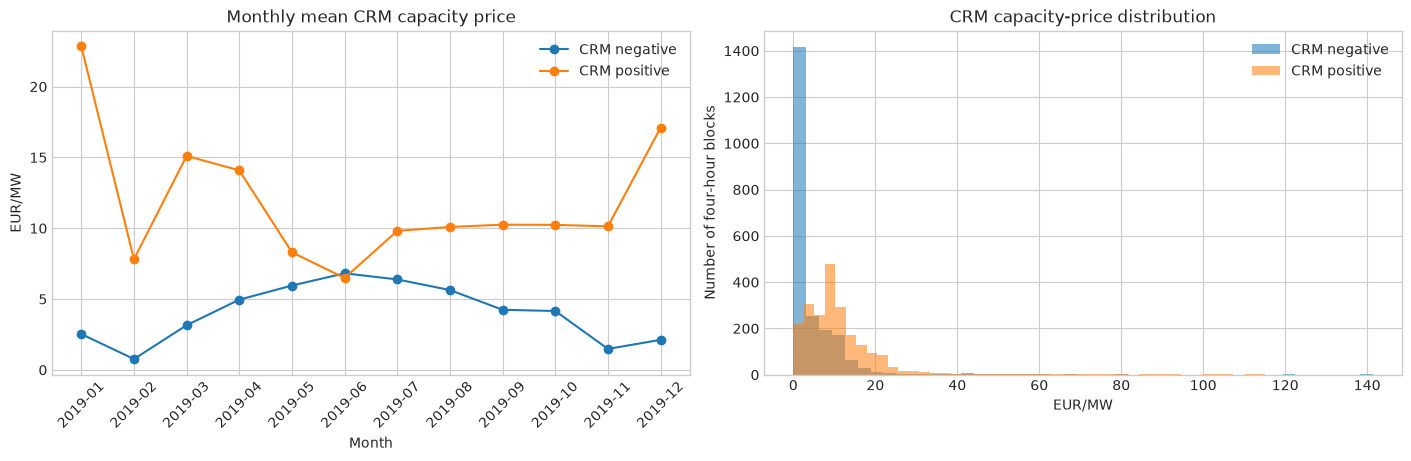

Both CRM markets clear every four hours and have zero supply-demand imbalance in this result. The analysis displays the positive magnitude of each direction's capacity remuneration.


In [9]:
# Monthly outcomes and capacity-price distributions.
crm_monthly = crm.groupby(["month", "market_id"]).agg(
    mean_capacity_price=("capacity_price", "mean"),
    mean_cleared_capacity_mw=("supply_volume", "mean"),
    capacity_price_volatility=("capacity_price", "std"),
).reset_index()
display(crm_monthly.pivot(index="month", columns="market_id", values=["mean_capacity_price", "mean_cleared_capacity_mw"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for market, frame in crm_monthly.groupby("market_id"):
    label = "CRM positive" if market == "CRM_pos" else "CRM negative"
    axes[0].plot(frame["month"].astype(str), frame["mean_capacity_price"], marker="o", label=label)
for market, frame in crm.groupby("market_id"):
    label = "CRM positive" if market == "CRM_pos" else "CRM negative"
    axes[1].hist(frame["capacity_price"], bins=45, alpha=0.55, label=label)
axes[0].set(title="Monthly mean CRM capacity price", xlabel="Month", ylabel="EUR/MW")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[1].set(title="CRM capacity-price distribution", xlabel="EUR/MW", ylabel="Number of four-hour blocks")
axes[1].legend()
plt.show()

print("Both CRM markets clear every four hours and have zero supply-demand imbalance in this result. "
      "The analysis displays the positive magnitude of each direction's capacity remuneration.")
